(sec:nonlinear_regression)=

# Nonlinear Regression

In the previous sections, we learned about linear regression, which allows us 
to model linear relationships between variables. While many physical 
relationships are linear or can be formulated as such, there are also many 
nonlinear relationships that we want to model. In the context of the 
least squares method, we simply replace the model $\hat{f(\beta; x)}$ in 
Eq. {eq}`eq:least_squares_opt` with a nonlinear function. However, 
in this case, an analytical solution like 
the corresponding linear-system equation from the previous section is not always possible, 
which is why numerical optimisation methods must be used.

## Application

### Reaction Kinetics

In the Physical Chemistry lab, you probably performed the experiment
"Determination of the rate constant and activation energy of the
Manganese(III)-trioxalate decomposition reaction", also known as 
"Mn-Zerfall", by measuring the absorbance $A$ as a function of time $t$ and
fitting the measurement data to determine the rate constant $k$. 
The underlying relationship is exponential:
:::{math}
:enumerated: false

  A(t) = A_0\, \mathrm{e}^{-k t}
:::
with the parameters $A_0$ and $k$, i.e. $\beta = (A_0, k)^\intercal$.

Here, we have $A(t) = \hat{f}(\beta; t)$, and we can formulate the regression
problem using the least squares loss function as the following
optimisation problem:
:::{math}
:label: eq:least_squares_exp_opt

  \beta^{* } = \argmin_{\beta\in\mathbb{R}^2} \sum_{i=1}^N\, (A_i - A_0\, \mathrm{e}^{-k t_i})^2,
:::
where $A_i$ is the measured absorbance at time $t_i$.

For the implementation, we first import the required modules and libraries
as always:


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

Next, we need to provide the data in the form of arrays. Since we have
quite a few data points here, manually typing them in would be quite tedious.
Therefore, we use the function 
[`np.loadtxt`](https://numpy.org/doc/stable/reference/generated/numpy.loadtxt.html)
to read the data from a text file. For the lecture note, we use the measurements taken at 20 °C[^1], stored in the text file `mn_decay_20.txt` 
(<a href="../assets/data/regression/mn_decay_20.txt" download>download here</a>).
[^1]: The authors thank XXX and YYY for providing the data.

The file has two columns containing the values for time $t$ and absorbance $A$. The first few lines of the file look like this:

```{literalinclude} ../assets/data/regression/mn_decay_20.txt
:language: text
:lines: 1-10
```

To read the data, the function `np.loadtxt` requires the filename:

```python
time, absorbance = np.loadtxt('mn_decay_20.txt', unpack=True)
```

In [45]:
time, absorbance = np.loadtxt('../assets/data/regression/mn_decay_20.txt', unpack=True)

Here, the file is stored separately from the notebook source, so in practice the correct path must be provided when loading it. The optional argument `unpack=True` 
makes the columns of the file output separately and stores them as arrays
`time` and `absorbance`. If we set `unpack=False`, which is also the default
value, the function would return a 2D array in which the columns are
combined. The first line of this file starts with a comment character `#`,
which causes `np.loadtxt` to ignore this line.

:::{note} Note

With the optional argument `comments`, we can change the character used for comments.
:::

Now we can define the model:

In [46]:
def exp_decay(t, a0, k):
    return a0 * np.exp(-k * t)

Although `t` is an array and `k` is a scalar, the multiplication
`-k * t` works element-wise. In this case, `k` is also interpreted as an array,
which is called
[broadcasting](https://numpy.org/doc/stable/user/basics.broadcasting.html).
The function `np.exp` calculates the element-wise exponential
of the array. The result is again an array, which we multiply with 
the scalar `a0`.

Next, we define the objective function in
Eq. {eq}`eq:least_squares_exp_opt`:

In [47]:
def objective_function(beta, x, y):
    # x: time; y: absorbance
    a0, k = beta
    return np.sum((y - exp_decay(x, a0, k))**2)

Now we use the `minimize` function to solve this
optimisation problem:

In [48]:
beta_guess = (1.0, 0.01)
res = minimize(
    objective_function, beta_guess, method='Nelder-Mead', 
    args=(time, absorbance),
)
a0, k = res.x

print(f'k = {k} s^-1')
print(f'A0 = {a0}')

k = 0.0015803420166022831 s^-1
A0 = 1.3226740595808124


Here, we applied the Nelder-Mead method with the initial parameters
$A_0^0 = 1$ and $k^0 = 0.01$. To print the result with the
`print` command, we placed an `f` before the string.
This indicates that the string is a so-called
[f-string](https://realpython.com/python-f-strings/#doing-string-interpolation-with-f-strings-in-python)
in which we can embed variables with curly braces `{}`.
In fact, f-strings can do much more, which we will see in the future.

Finally, we can plot the results:


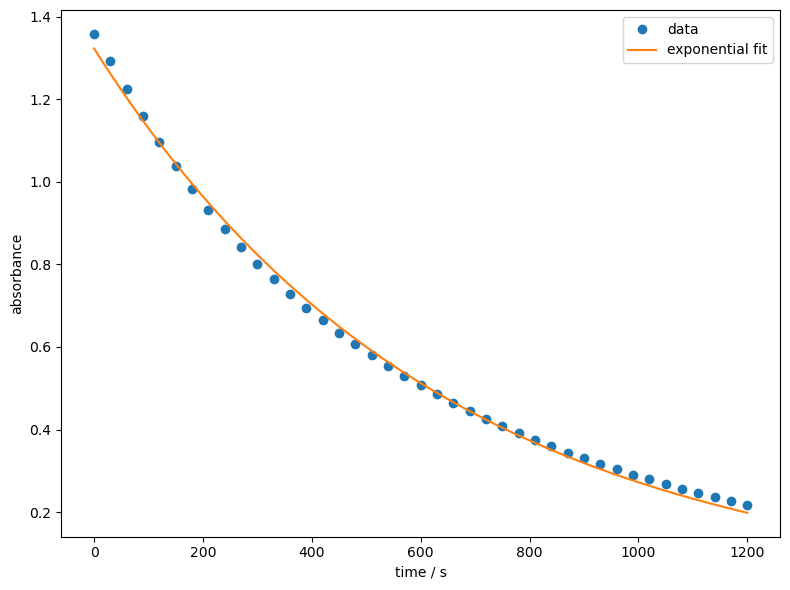

In [49]:
fig, ax = plt.subplots(figsize=(8, 6))
time_interp = np.linspace(time.min(), time.max(), 1000)

ax.plot(time, absorbance, 'o', label='data')
ax.plot(time_interp, exp_decay(time_interp, a0, k), label='exponential fit')

ax.set_xlabel('time / s')
ax.set_ylabel('absorbance')
ax.legend()

fig.tight_layout()
plt.show()

You should be familiar with most of the functions in the above code block from
section {ref}`sec:linear_regression`. One difference is the use of the function
[`np.linspace`](https://numpy.org/doc/stable/reference/generated/numpy.linspace.html),
which generates times between the measurement points so that we can
use the regression model for interpolation.
This function takes three arguments: the start value, the end value, and
the number of points to be generated. It then produces an array
with evenly distributed values between the start and end value.

Another new function is
[`fig.tight_layout()`](https://matplotlib.org/stable/api/_as_gen/matplotlib.figure.Figure.tight_layout.html), which automatically adjusts the layout of the plot.
We can see from the following diagram that the exponential function describes the data
very well.

Some of you might ask why we didn't linearise the function to use
linear regression, which is a valid question. In fact, it is possible 
to linearise the function by
taking the logarithm of both sides of the equation:
:::{math}
:enumerated: false

  \ln(A(t)) = - k t + \ln(A_0),
:::
which has the form of a linear equation $y = mx + b$.
A linear regression using this equation, however, does not yield the
same results, as you can see in the following diagram:



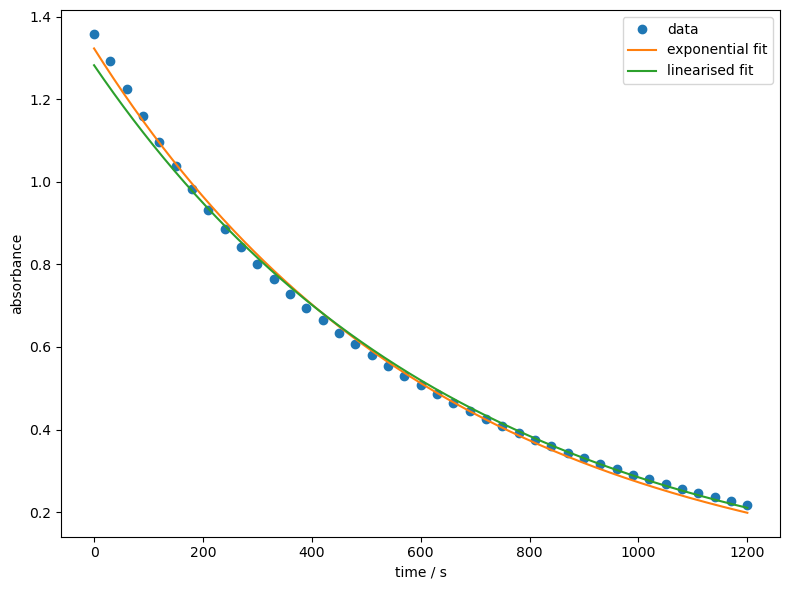

In [7]:
beta1, beta0 = np.polyfit(time, np.log(absorbance), 1)
a0_lin = np.exp(beta0)
k_lin = -beta1

fig, ax = plt.subplots(figsize=(8, 6))
time_interp = np.linspace(time.min(), time.max(), 1000)

ax.plot(time, absorbance, 'o', label='data')
ax.plot(time_interp, exp_decay(time_interp, a0, k), label='exponential fit')
ax.plot(time_interp, a0_lin * np.exp(-k_lin * time_interp), label='linearised fit')

ax.set_xlabel('time / s')
ax.set_ylabel('absorbance')
ax.legend()
fig.tight_layout()
plt.show()

As a voluntary exercise, you can try to reproduce the diagram above.
It is easy to see that the linearised fit does not match the data as well.
This is because linear regression does not treat the errors between the data points and the linearised model equally. The resulting parameters


In [8]:
print(f'k_lin = {k_lin} s^-1')
print(f'A0_lin = {a0_lin}')

k_lin = 0.0015056049661054242 s^-1
A0_lin = 1.282012780370813


are indeed quite different from the previous ones.
Therefore, it is often necessary to perform nonlinear regressions on the original
data rather than using linear models with linearised data.

### Titration Curve

Another experiment commonly performed in analytical chemistry labs is the titration of a strong base against a strong acid using a pH meter. When you did this experiment,
you probably had to plot the values on millimeter paper and determine the
equivalence point based on the position of the pH jump. This is tedious
and inaccurate, as only the few data points near the steep rise are
considered.

Since the pH curve is a function of the amount of base added, we can
model it using nonlinear regression and determine the equivalence point
with much higher accuracy.

The $\mathrm{H^+}$ concentration during the titration of a strong
base against a strong acid is (under certain approximations) given by:
:::{math}
:label: eq:titration_sasb_hplus

  [\mathrm{H^+}] = \frac{\Delta + \sqrt{\Delta^2 + 4K_w}}{2}\,,
:::
where $\Delta = [\mathrm{A^-}] - [\mathrm{B^+}]$ is the concentration difference
between the counterions of the acid $\mathrm{A^-}$ and the base $\mathrm{B^+}$.
$K_w$ is the ion product of water.

Since strong acids and bases dissociate completely, the concentrations of their
counterions can be expressed as follows:
:::{math}
:enumerated: false

  \begin{aligned}
    [\mathrm{A^-}] &= \frac{n_\mathrm{A}}{V} 
      = \frac{c_\mathrm{A}^0 V^0}{V^0 + V_\mathrm{B}} \\
    [\mathrm{B^+}] &= \frac{n_\mathrm{B}}{V}
      = \frac{c_\mathrm{B}^0 V_\mathrm{B}}{V^0 + V_\mathrm{B}}\,,
  \end{aligned}
:::
where $c_\mathrm{A}^0$ and $c_\mathrm{B}^0$ are the concentrations of the acid
and base to be analysed, $V^0$ is the initial volume of the sample solution,
and $V_\mathrm{B}$ is the volume of the added base.

The pH value can be calculated from the $\mathrm{H^+}$ concentration:
:::{math}
:label: eq:titration_sasb_ph

  \mathrm{pH} = -\log_{10} \left( \frac{[\mathrm{H^+}]}{1\ \mathrm{M}} \right)\,.
:::

By combining the equations {eq}`eq:titration_sasb_hplus` and
{eq}`eq:titration_sasb_ph` into a single function, we obtain the model
$f(\beta; V_\mathrm{B})$, where
$\beta = (c_\mathrm{A}^0, V^0)^\intercal$.

As before, we first implement the model and the objective function:

In [9]:
def titration_sasb_model(v_b, c0_b, c0_a, v0):
    k_w = 1e-14
    c_a = c0_a * v0 / (v0 + v_b)
    c_b = c0_b * v_b / (v0 + v_b)
    delta = c_a - c_b
    c_h = 0.5 * (delta + np.sqrt(delta**2 + 4 * k_w))
    ph = -np.log10(c_h)
    return ph

In [10]:
def objective_function(beta, x, y, c0_b):
    # x: v_b; y: ph
    c0_a, v0 = beta
    ph_fit = titration_sasb_model(x, c0_b, c0_a, v0)
    return np.sum((y - ph_fit)**2)

Although the function of the pH value is relatively complicated, we can
simplify the implementation of the function in Python significantly by
defining intermediate variables, as in
Eq. {eq}`eq:titration_sasb_hplus`. The objective function is almost 
identical to that of the "Mn-Zerfall", with the main difference being 
the replacement of our model.

Just like in the previous example, we read the data from a text file
(<a href="../assets/data/regression/titration_sasb.txt" download>download here</a>):


```python
C0_B = 0.1  # mol/l
v_b, ph = np.loadtxt('titration_sasb.txt', unpack=True)
```

In [11]:
C0_B = 0.1  # mol/l
v_b, ph = np.loadtxt('../assets/data/regression/titration_sasb.txt', unpack=True)

Additionally, we have defined the concentration of the titrant `C0_B`.
According to the general convention, all constants in Python should be written 
in uppercase letters.
After that, we can perform the nonlinear regression
and plot the results:


In [12]:
beta_guess = (0.01, 100)
res = minimize(
    objective_function, 
    beta_guess, 
    args=(v_b, ph, C0_B),
    method='Nelder-Mead',
    options={'maxiter': 1000},
)
print(res.message)

c0_a, v0 = res.x
print(f'c0_a = {c0_a} mol/l')
print(f'v0 = {v0} ml')
print(f'n0_a = {c0_a * v0} mmol')

Optimization terminated successfully.
c0_a = 0.01806877008177348 mol/l
v0 = 97.95180652737798 ml
n0_a = 1.7698686712375518 mmol


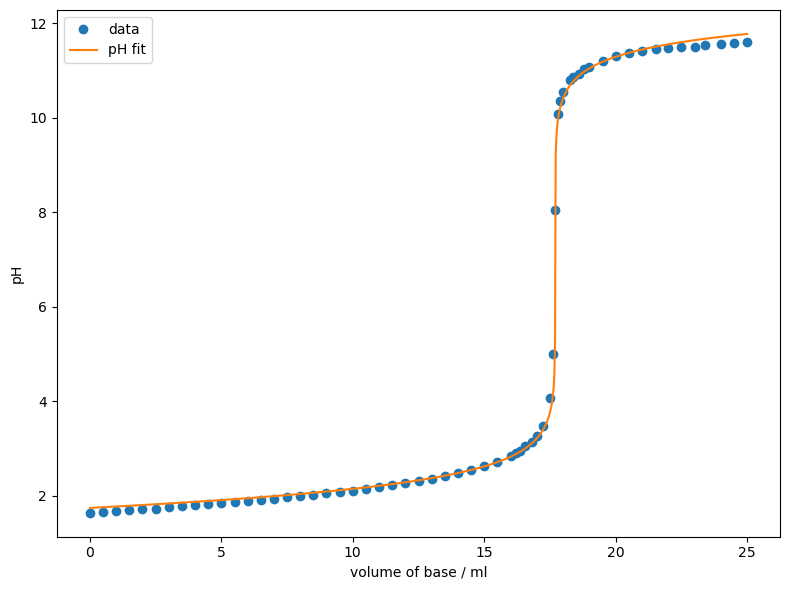

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))
v_b_interp = np.linspace(v_b.min(), v_b.max(), 1000)

ax.plot(v_b, ph, 'o', label='data')
ax.plot(
    v_b_interp, 
    titration_sasb_model(v_b_interp, C0_B, c0_a, v0), 
    label='pH fit',
)

ax.set_xlabel('volume of base / ml')
ax.set_ylabel('pH')
ax.legend()

fig.tight_layout()
plt.show()

From the optimised parameters, we determined the amount of the analyte
$n_\mathrm{A}^0 = 1.7698\ \mathrm{mmol}$. The corresponding diagram should 
look like this:
Although the fit is not perfect at the beginning and end of the curve,
the agreement near the equivalence point is excellent.

You may have wondered why the optimised parameters $c_\mathrm{A}^0$
and $V^0$ are not explicitly listed here, but only their product.
:::{warning} Warning: correlated parameters
The model parameters $\beta$ can be correlated, i.e., changing
two or more parameters leads to a similar change in the
objective function. This circumstance may indicate so-called 
*overfitting* of the data by the model.
In this case, it is advisable to check whether the model can also
be simplified with fewer parameters.

In our case, the parameters $c_\mathrm{A}^0$ and $V^0$ are correlated,
as it is the amount of the analyte $n_\mathrm{A}^0$ that has a significant
impact on the titration curve. The initial volume $V^0$, on the other hand,
plays only a minor role, which is why the product $c_\mathrm{A}^0 V^0$ serves
as an approximate single parameter. Nevertheless, $V^0$ is an important
parameter here, as it is on the same order of magnitude as $V_\mathrm{B}$ and
the dilution cannot be neglected. However, since we only need the product
$c_\mathrm{A}^0 V^0$ for the titration analysis,
the correlation of the parameters does not bother us here.
:::

:::{tip} Tip
Change the initial guesses and observe how the
optimised parameters change, but their product remains nearly constant.
:::

Finally, it should be emphasised again that it is often important to
perform the regression on the original data and not to use
transformed data. In the case of the acid-base titration, one might think
of fitting $[\mathrm{H^+}]$ instead of the pH value. For the same
reasons as before, this is not sensible: Since the same error on the pH scale 
leads to larger
errors at higher $\mathrm{H^+}$ concentrations and smaller errors
at lower $\mathrm{H^+}$ concentrations, the
data points at higher $\mathrm{H^+}$ concentrations are fitted better.
This leads to a distortion of the results, as can be seen in the following
diagram:

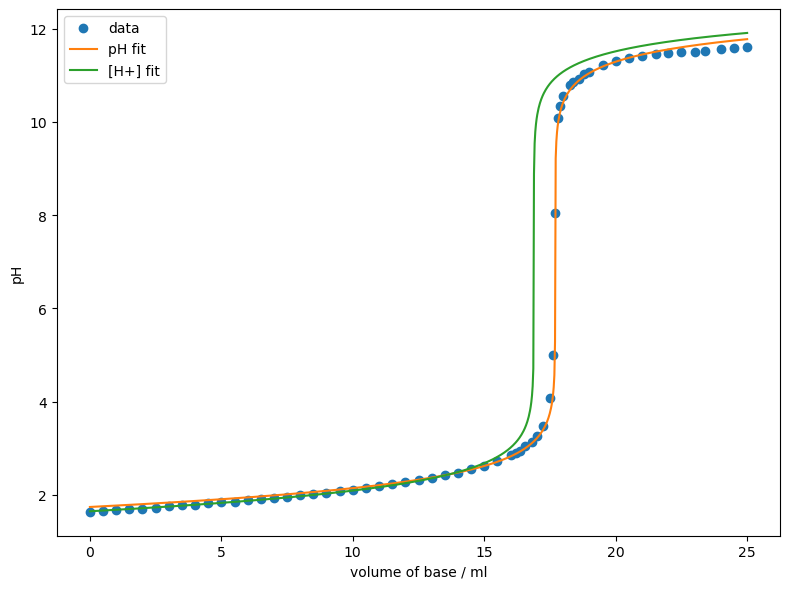

In [14]:
def titration_sasb_model_ch(v_b, c0_b, c0_a, v0):
    k_w = 1e-14
    c_a = c0_a * v0 / (v0 + v_b)
    c_b = c0_b * v_b / (v0 + v_b)
    delta = c_a - c_b
    c_h = 0.5 * (delta + np.sqrt(delta**2 + 4 * k_w))
    return c_h

def objective_function_ch(beta, *args):
    c0_a, v0 = beta
    c0_b, v_b, ph = args
    c_h = np.power(10, -ph)
    c_h_fit = titration_sasb_model_ch(v_b, c0_b, c0_a, v0)
    return np.sum((c_h - c_h_fit)**2)

res = minimize(
    objective_function_ch,
    beta_guess,
    args=(C0_B, v_b, ph),
    method='Nelder-Mead',
)

fig, ax = plt.subplots(figsize=(8, 6))
v_b_interp = np.linspace(v_b.min(), v_b.max(), 1000)
ax.plot(v_b, ph, 'o', label='data')
ax.plot(
    v_b_interp, 
    titration_sasb_model(v_b_interp, C0_B, c0_a, v0), 
    label='pH fit',
)
ax.plot(
    v_b_interp,
    -np.log10(titration_sasb_model_ch(v_b_interp, C0_B, res.x[0], res.x[1])),
    label='[H+] fit',
)
ax.set_xlabel('volume of base / ml')
ax.set_ylabel('pH')
ax.legend()
fig.tight_layout()
plt.show()

It can be seen that the regression on $[\mathrm{H^+}]$ favours the earlier data points, resulting in a completely incorrect determination of the equivalence point.



---

## Exercises and References

### Self-Study Questions

1. Explain why nonlinear regression is necessary for the Mn decay experiment, even though the relationship can be linearized by taking the logarithm. What are the consequences of using linear regression on the linearised data?

2. In the titration curve example, why are the parameters $c_\mathrm{A}^0$ and $V^0$ correlated? How does this correlation affect the optimisation process, and why is it acceptable in this case?

### Challenge Questions

1. The Mn decay experiment could be extended to include temperature dependence of the rate constant $k$ through the Arrhenius equation $k = A\exp(-E_a/RT)$. How would you modify the model and optimisation approach to determine both the pre-exponential factor $A$ and the activation energy $E_a$ from measurements at different temperatures?

2. Try to reproduce the diagram of the titration curve with regression on $[\mathrm{H^+}]$ concentration.